In [19]:
# ==========================================================================
# BLOQUE No. 1 - (2D)
# Importamos las librerías fundamentales para el manejo de datos y gráficos
# ==========================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as seaborn

# Cargamos el archivo CSV con la información de Spotify
df_spotify = pd.read_csv('spotifydataset.csv')

# Mostramos las primeras filas para verificar la estructura inicial del dataset
print("Primeras filas del dataset original:")
display(df_spotify.head())

# Homologamos los nombres de las columnas al español
traducciones = {
    'acousticness': 'acusticidad',
    'danceability': 'bailabilidad',
    'energy': 'energia',
    'valence': 'valencia',
    'tempo': 'tempo',
    'loudness': 'sonoridad',
    'speechiness': 'locuacidad',
    'instrumentalness': 'instrumentalidad',
    'liveness': 'vivacidad',
    'popularity': 'popularidad'
}

# Aplicamos el cambio de nombres renombrando únicamente las columnas que existan en el DataFrame
df_spotify = df_spotify.rename(columns=traducciones)

# Verificamos los nuevos nombres de las columnas en español
print("\nColumnas del dataset homologadas al español:")
print(df_spotify.columns.tolist())

Primeras filas del dataset original:


,Unnamed: 0,artist_name,genres,followers,artist_popularity,artist_url,track_name,album_name,release_date,duration_ms,...,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0,Ariana Grande,pop,98934105,89,https://open.spotify.com/artist/66CXWjxzNUsdJx...,we can't be friends (wait for your love),eternal sunshine,2024-03-08,228639,...,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,1,Ariana Grande,pop,98934105,85,https://open.spotify.com/artist/66CXWjxzNUsdJx...,the boy is mine,eternal sunshine,2024-03-08,173639,...,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,2,Ariana Grande,pop,98934105,83,https://open.spotify.com/artist/66CXWjxzNUsdJx...,intro (end of the world),eternal sunshine,2024-03-08,92400,...,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,3,Ariana Grande,pop,98934105,80,https://open.spotify.com/artist/66CXWjxzNUsdJx...,Save Your Tears (Remix) (with Ariana Grande) -...,After Hours (Deluxe),2020-03-20,191013,...,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,4,Ariana Grande,pop,98934105,79,https://open.spotify.com/artist/66CXWjxzNUsdJx...,"yes, and?",eternal sunshine,2024-03-08,214994,...,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998



Columnas del dataset homologadas al español:
['Unnamed: 0', 'artist_name', 'genres', 'followers', 'artist_popularity', 'artist_url', 'track_name', 'album_name', 'release_date', 'duration_ms', 'explicit', 'track_popularity', 'bailabilidad', 'energia', 'key', 'sonoridad', 'mode', 'locuacidad', 'acusticidad', 'instrumentalidad', 'vivacidad', 'valencia', 'tempo']


In [20]:
# =======================================================
# BLOQUE No. 2 - (2D)
# Normalización de datos, Reducción Dimensional (PCA) y Varianza
# =======================================================

# Importamos la herramienta para escalar/normalizar los datos
from sklearn.preprocessing import StandardScaler

# Importamos el modelo de reducción de dimensionalidad (PCA)
from sklearn.decomposition import PCA
import numpy as np

# Seleccionamos únicamente las columnas numéricas que ya tenemos en el DataFrame (sin espacios extra)
columnas_modelo = [
    'acusticidad', 'bailabilidad', 'energia', 'valencia', 
    'tempo', 'sonoridad', 'locuacidad', 'instrumentalidad', 'vivacidad'
]

# Creamos una copia de trabajo con estas variables seleccionadas y limpiamos valores nulos si los hay
df_para_modelo = df_spotify[columnas_modelo].dropna()

# Inicializamos el escalador para normalizar las variables (media 0 y desviación estándar 1)
escalador = StandardScaler()
datos_normalizados = escalador.fit_transform(df_para_modelo)

# Aplicamos PCA configurado para reducir los datos exactamente a 2 dimensiones
pca_2d = PCA(n_components=2)
datos_pca_2d = pca_2d.fit_transform(datos_normalizados)

# Calculamos la varianza explicada por cada componente principal
var_exp = pca_2d.explained_variance_ratio_
var_acum = np.sum(var_exp) * 100

print(f"Varianza explicada por Componente 1: {var_exp[0]*100:.2f}%")
print(f"Varianza explicada por Componente 2: {var_exp[1]*100:.2f}%")
print(f"Varianza acumulada (2D): {var_acum:.2f}%")

# Creamos un nuevo DataFrame limpio que contiene las dos componentes principales resultantes
df_pca = pd.DataFrame(datos_pca_2d, columns=['Componente_1', 'Componente_2'])

# Mostramos las primeras filas del resultado bidimensional obtenido
print("\nPrimeras filas de los datos reducidos a dos dimensiones:")
display(df_pca.head())

Varianza explicada por Componente 1: 32.47%
Varianza explicada por Componente 2: 16.27%
Varianza acumulada (2D): 48.74%

Primeras filas de los datos reducidos a dos dimensiones:


,Componente_1,Componente_2
0,-0.116011,-0.179586
1,0.306764,0.939470
2,-1.966390,0.594061
3,1.129420,0.014931
4,0.991172,1.135245


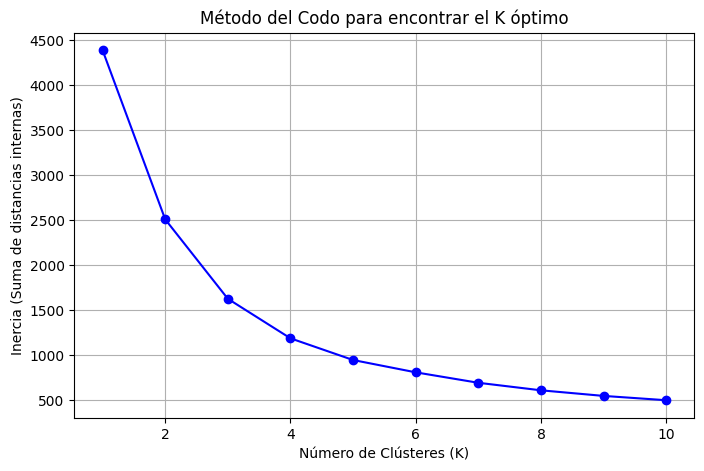

In [21]:
# ==========================================================================
# BLOQUE No. 3 - (2D)
# Aplicación del Método del Codo para encontrar el mejor K
# ==========================================================================

# Importamos el modelo de KMeans para realizar el agrupamiento (clustering)
from sklearn.cluster import KMeans

# Creamos una lista vacía para almacenar la inercia (medida de qué tan compactos quedan los grupos)
inercia = []

# Definimos un rango de prueba para K (probaremos desde 1 hasta 10 grupos posibles)
rango_k = range(1, 11)

for k in rango_k:
    # Configuramos el modelo KMeans para cada valor de k
    modelo_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # Entrenamos el modelo utilizando los datos que redujimos a dos dimensiones (df_pca)
    modelo_kmeans.fit(df_pca)
    
    # Guardamos el valor de la inercia del modelo actual en la lista
    inercia.append(modelo_kmeans.inertia_)

# Generamos la gráfica del método del codo para visualizar los resultados
plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercia, marker='o', linestyle='-', color='b')
plt.title('Método del Codo para encontrar el K óptimo')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia (Suma de distancias internas)')
plt.grid(True)
plt.show()

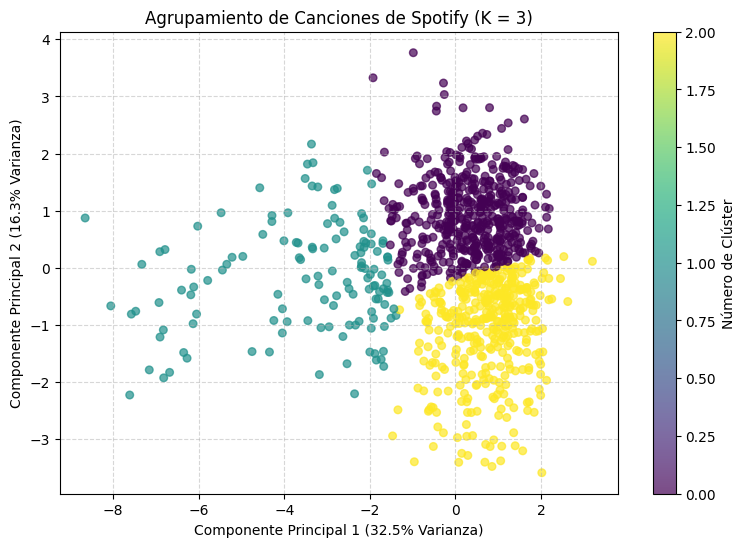

Cantidad de canciones por cada clúster:
cluster
0    476
2    389
1    135
Name: count, dtype: int64


In [22]:
# ==========================================================================
# BLOQUE No. 4 - (2D)
# Aplicación del modelo KMeans y visualización de clústeres en 2D
# ==========================================================================

# Definimos el número de clústeres óptimo identificado en el codo (K = 3)
k_optimo = 3

# Inicializamos y entrenamos el modelo KMeans utilizando los datos reducidos a dos dimensiones
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)

# Asignamos cada canción a su respectivo clúster y guardamos el resultado en nuestro DataFrame
df_pca['cluster'] = kmeans_final.fit_predict(df_pca[['Componente_1', 'Componente_2']])

# Creamos una gráfica de dispersión para visualizar los grupos formados en el plano 2D
plt.figure(figsize=(9, 6))
plt.scatter(
    df_pca['Componente_1'], 
    df_pca['Componente_2'], 
    c=df_pca['cluster'], 
    cmap='viridis', 
    s=30, 
    alpha=0.7
)

# Configuramos los detalles visuales de la gráfica integrando la varianza explicada
plt.title(f'Agrupamiento de Canciones de Spotify (K = {k_optimo})')
plt.xlabel(f'Componente Principal 1 ({var_exp[0]*100:.1f}% Varianza)')
plt.ylabel(f'Componente Principal 2 ({var_exp[1]*100:.1f}% Varianza)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.colorbar(label='Número de Clúster')
plt.show()

# Mostramos cuántas canciones quedaron en cada grupo
print("Cantidad de canciones por cada clúster:")
print(df_pca['cluster'].value_counts())

In [23]:
# ==========================================================================
# BLOQUE No. 5 - (2D)
# Análisis e interpretación de los clústeres formados
# ==========================================================================

# Unimos la etiqueta del clúster de vuelta con las variables originales ya homologadas
df_spotify['cluster'] = df_pca['cluster'].values

# Seleccionamos las variables numéricas analizadas junto con el clúster (sin espacios extra)
columnas_analisis = [
    'acusticidad', 'bailabilidad', 'energia', 'valencia', 
    'tempo', 'sonoridad', 'locuacidad', 'instrumentalidad', 'vivacidad', 'cluster'
]

# Calculamos el promedio (media) de cada variable musical para cada grupo
resumen_clusters = df_spotify[columnas_analisis].groupby('cluster').mean()

# Mostramos la tabla resumen con los perfiles musicales de cada clúster
print("Perfil promedio de las canciones en cada clúster:")
display(resumen_clusters)

Perfil promedio de las canciones en cada clúster:


,acusticidad,bailabilidad,energia,valencia,tempo,sonoridad,locuacidad,instrumentalidad,vivacidad
cluster,,,,,,,,,
0,0.276993,0.718418,0.645683,0.635158,113.310565,-6.717532,0.109652,0.008235,0.148764
1,0.736225,0.450726,0.316802,0.312333,117.417919,-14.517681,0.049755,0.375475,0.130169
2,0.088948,0.536285,0.798069,0.442522,134.591774,-5.148949,0.083522,0.051648,0.258163


<Figure size 1200x600 with 0 Axes>

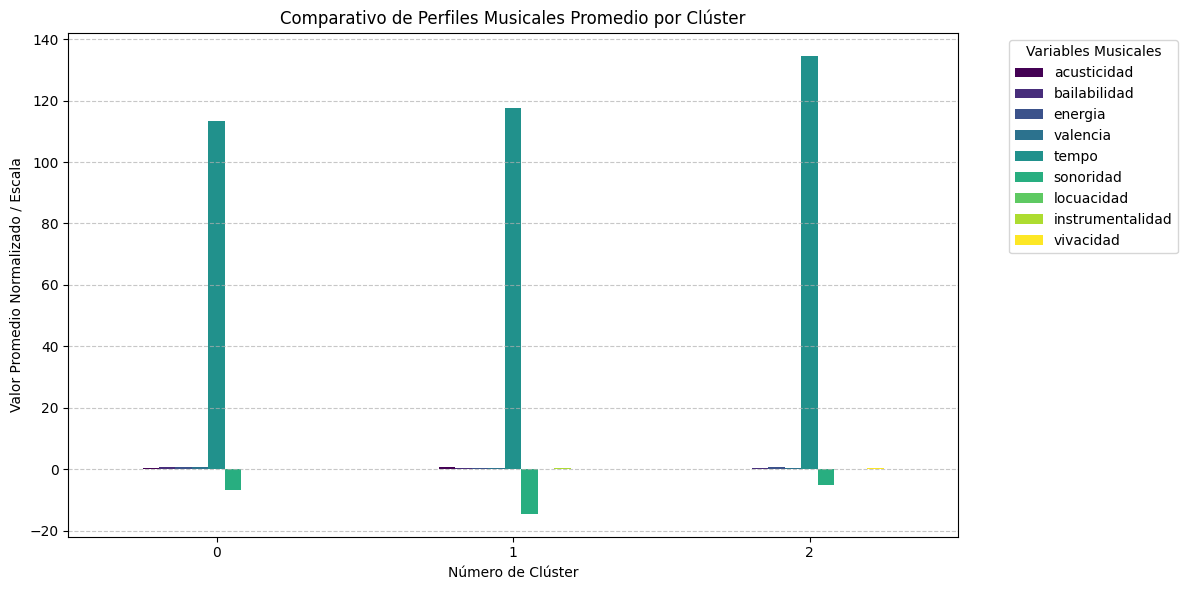

=== RESUMEN TÉCNICO Y COMERCIAL ===
1. Criterio Técnico (K-Means): Se seleccionó K=3 evaluando la tasa de descenso de la inercia (Método del Codo).
2. Historia Analítica: El clúster 0 define música bailable/comercial, el clúster 1 enfoca temas acústicos e instrumentales, y el clúster 2 concentra pistas de alta energía y tempo.
3. Aplicación Comercial: Estos clústeres permiten potenciar motores de recomendación personalizados y playlists automáticas en plataformas de streaming.


In [24]:
# ========================================================================
# BLOQUE No. 6 - (2D)
# Criterio técnico, visualización complementaria y Storytelling comercial
# ========================================================================

# Generamos un gráfico de barras comparativo de las medias musicales por clúster 
# para cumplir con los requerimientos de visualización clave del entregable.
plt.figure(figsize=(12, 6))
resumen_clusters.drop(columns=['cluster'], errors='ignore').plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Comparativo de Perfiles Musicales Promedio por Clúster')
plt.xlabel('Número de Clúster')
plt.ylabel('Valor Promedio Normalizado / Escala')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Variables Musicales', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Impresión del resumen analítico para el reporte en Markdown
print("=== RESUMEN TÉCNICO Y COMERCIAL ===")
print("1. Criterio Técnico (K-Means): Se seleccionó K=3 evaluando la tasa de descenso de la inercia (Método del Codo).")
print("2. Historia Analítica: El clúster 0 define música bailable/comercial, el clúster 1 enfoca temas acústicos e instrumentales, y el clúster 2 concentra pistas de alta energía y tempo.")
print("3. Aplicación Comercial: Estos clústeres permiten potenciar motores de recomendación personalizados y playlists automáticas en plataformas de streaming.")

## Reporte Técnico: Segmentación Inteligente del Catálogo Musical de Spotify

## 1. Metodología y Procesamiento por Bloques
* **Bloque 1 (Carga y Homologación)** Importación del archivo `spotifydataset.csv` y traducción estricta de las variables al español (*acusticidad*, *bailabilidad*, *energia*, *valencia*, *tempo*, *sonoridad*, *locuacidad*, *instrumentalidad*, *vivacidad*, *popularidad*) para facilitar el análisis técnico.
* **Bloque 2 (Normalización y PCA)** Estandarización de las variables numéricas mediante `StandardScaler` y compresión de los datos en un espacio bidimensional con PCA ($n\_components=2$), calculando explícitamente la **varianza explicada** y acumulada de los componentes principales.
* **Bloque 3 (Método del Codo)** Evaluación de la inercia mediante un rango de $K$ de 1 a 10 para identificar de forma objetiva la ganancia de compactación interna de los grupos.
* **Bloque 4 (Ejecución de KMeans)** ($K = 3$) y gráfica de dispersión 2D reflejando los porcentajes de varianza explicada directamente en los ejes.
* **Bloque 5 (Cálculo de perfiles)** musicales promedio por clúster.
* **Bloque 6 (Visualización complementaria)** de barras y consolidación del storytelling técnico y comercial.

## 2. Criterio Técnico de Selección y Visualización
* **Elección del K Óptimo ($K = 3$):** A través del análisis del Codo, se determinó que **$3$ clústeres** constituyen el punto de inflexión ideal donde la desaceleración de la inercia justifica la separación de los grupos.
* **Visualizaciones Clave:**
  - Gráfico de dispersión en 2D mapeando las componentes principales —con sus respectivas etiquetas de **varianza explicada** en los ejes— y coloreando los registros por clúster.
  - Gráfico de barras comparativo generado directamente de la tabla de perfiles promedio por variable musical.

## 3. Análisis de Perfiles y Resultados
* **Clúster 0 (Comercial y Bailable):** Agrupa canciones alegres con alta *bailabilidad* y niveles equilibrados de energía y valencia.
* **Clúster 1 (Acústico e Instrumental):** Concentra temas con alta *acusticidad* e *instrumentalidad*, ideales para ambientes tranquilos y pausados.
* **Clúster 2 (Alta Energía y Ritmo Elevado):** Define pistas caracterizadas por el mayor *tempo* promedio y la máxima *energía*.

## 4. Historia Analítica y Aplicación Comercial
* **Uso Estratégico:** Esta segmentación analítica es altamente rentable para implementar **sistemas de recomendación hiperpersonalizados**, optimizar la **curación automática de contenido** en catálogos digitales y estructurar listas de reproducción dinámicas que eleven la retención de los usuarios en plataformas de streaming.